In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Tarea 1 — Segmentación retórica (SciBETO + Llama 3.1 + GPT)


## Cambios vs. notebook anterior

| Aspecto | Detalle |
|---|---|
| Neutralización train/test | **`USE_SOFT_MASK=True` en ambos** — alinea train e inferencia |
| SciBETO hiperparámetros | `batch=16, grad_accum=1, 5 ep` (A100-optimized) + early stopping |
| Llama generación | Solo `do_sample=False` (greedy) |
| GPT prompt | Prompt dinámico según `EXCLUDE_CONTR` |
| GPT API | `async` paralelo (~3-5 min) |
| Reproducibilidad | `set_seed(42)` en numpy, torch, transformers |
| Matriz de confusión | **Por cada modelo** + classification_report |
| Guardado de pesos | **Directamente a Drive** + ZIP + JSONs auxiliares |
| `label_map.json` + `soft_mask_keywords.json` | **Generados** (críticos para integración con backend) |

## Requisitos previos en Drive

`/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/` debe contener:
- `dataset_train.csv`
- `dataset_val.csv`
- `dataset_test.csv`



## 1. Setup

In [2]:
!pip install -q transformers datasets evaluate accelerate scikit-learn bitsandbytes openai

#Instalar W&B
!pip install wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.2 MB/s eta 0:00:00


In [3]:
#Login  W&B
from google.colab import userdata
import wandb

wandb.login(key=userdata.get("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: edwincifuentes (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import os, json, shutil, re, time, asyncio
import pandas as pd
import numpy as np
import torch

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM,
    TrainingArguments, Trainer, EarlyStoppingCallback, BitsAndBytesConfig,
    set_seed,
)
import evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ── Reproducibilidad ──
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Configuración global ──
EXCLUDE_CONTR  = True            # 7 clases (sin CONTR). Recomendado por hallazgos previos.
BASE_LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']
LABELS  = [l for l in BASE_LABELS if l != 'CONTR'] if EXCLUDE_CONTR else BASE_LABELS
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}
n_classes = len(LABELS)

# ── Rutas ──
DATA_DIR    = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets'
RESULTS_DIR = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab'
MODELS_DIR  = f'{RESULTS_DIR}/scibeto-t1-7c' if EXCLUDE_CONTR else f'{RESULTS_DIR}/scibeto-t1-8c'

os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Verificación GPU ──
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"\nClases activas ({n_classes}): {LABELS}")
print(f"Resultados se guardan en: {RESULTS_DIR}")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.3 GB

Clases activas (7): ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'LIM', 'CONC']
Resultados se guardan en: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab


## 2. Carga de datos y re-neutralización con SOFT MASK

**Por qué re-neutralizamos:** la versión anterior del split en Drive aplicó `matched_keywords` al train y `keywords` al test (dos columnas distintas → dos distribuciones distintas de máscaras). Para esta corrida final aplicamos **SOFT_MASK** (lista fija) a los tres splits, garantizando coherencia interna y replicabilidad en inferencia (el backend solo puede aplicar SOFT_MASK en producción, porque no tiene `matched_keywords` para texto nuevo).

In [5]:
SOFT_MASK_KEYWORDS = [
    'introducción', 'introduccion', 'objetivos', 'justificacion', 'justificación',
    'antecedentes', 'estado del arte', 'metodología', 'metodologia',
    'materiales y métodos', 'resultados', 'discusión', 'discusion',
    'conclusiones', 'trabajo futuro', 'limitaciones', 'recomendaciones',
]
# CRÍTICO: ordenar por longitud descendente para evitar reemplazos parciales
SOFT_MASK_KEYWORDS.sort(key=len, reverse=True)

_MASK_PATTERNS = [
    (re.compile(rf'\b{re.escape(kw)}\b', re.IGNORECASE), '[MASK]')
    for kw in SOFT_MASK_KEYWORDS
]

def apply_soft_mask(text: str) -> str:
    """Aplica la MISMA neutralización que usará el backend en inferencia."""
    out = str(text)
    for pat, repl in _MASK_PATTERNS:
        out = pat.sub(repl, out)
    return re.sub(r'\s+', ' ', out).strip()

def load_and_prepare(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # Filtro CONTR si entrenamos 7 clases
    if EXCLUDE_CONTR:
        df = df[df['category'] != 'CONTR'].copy()
    # Re-neutralizar SIEMPRE desde 'snippet' (la fuente cruda) con soft mask
    df['neutralized_snippet'] = df['snippet'].astype(str).apply(apply_soft_mask)
    df['label'] = df['category'].map(label2id)
    df = df[df['label'].notna()].copy()
    df['label'] = df['label'].astype(int)
    return df[['snippet', 'neutralized_snippet', 'category', 'label']]

train_df = load_and_prepare(f'{DATA_DIR}/dataset_train.csv')
val_df   = load_and_prepare(f'{DATA_DIR}/dataset_val.csv')
test_df  = load_and_prepare(f'{DATA_DIR}/dataset_test.csv')

print(f"Train: {len(train_df):,d}  |  Val: {len(val_df):,d}  |  Test: {len(test_df):,d}\n")
print('Distribución TRAIN:')
print(train_df['category'].value_counts().sort_index().to_string())
print('\nDistribución TEST (gold validado manualmente):')
print(test_df['category'].value_counts().sort_index().to_string())
print('\nMuestra neutralizada:')
print('  ORIGINAL: ', train_df.iloc[0]['snippet'][:140], '...')
print('  NEUTRAL:  ', train_df.iloc[0]['neutralized_snippet'][:140], '...')

Train: 10,694  |  Val: 1,906  |  Test: 1,401

Distribución TRAIN:
category
BACK     1516
CONC     1540
DISC     1539
INTRO    1529
LIM      1517
METH     1528
RES      1525

Distribución TEST (gold validado manualmente):
category
BACK     201
CONC     200
DISC     200
INTRO    200
LIM      200
METH     200
RES      200

Muestra neutralizada:
  ORIGINAL:  87  REVISTA CEDOTIC ISSN: 2539-1518  Vol. 3. No. 2. 79-104 Julio-Dic. 2018  renovación de sus registros calificados, y a la Resolución 2041  ...
  NEUTRAL:   87 REVISTA CEDOTIC ISSN: 2539-1518 Vol. 3. No. 2. 79-104 Julio-Dic. 2018 renovación de sus registros calificados, y a la Resolución 2041 del ...


## 3. Métricas compartidas y helpers de reporte

In [6]:
f1_metric       = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_micro": f1_metric.compute(predictions=preds, references=labels, average="micro")["f1"],
    }

def full_report(y_true_str, y_pred_str, model_name: str, save_to: str | None = None):
    """Imprime y opcionalmente persiste accuracy, macro/micro F1, classification_report y matriz de confusión."""
    # Las predicciones UNKNOWN cuentan como errores
    labels_for_metrics = LABELS
    acc      = accuracy_score(y_true_str, y_pred_str)
    macro_f1 = f1_score(y_true_str, y_pred_str, average='macro', labels=labels_for_metrics, zero_division=0)
    micro_f1 = f1_score(y_true_str, y_pred_str, average='micro', labels=labels_for_metrics, zero_division=0)
    unknown  = sum(1 for p in y_pred_str if p == 'UNKNOWN')

    print(f"\n{'='*60}\n{model_name}\n{'='*60}")
    print(f"Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}  |  Micro F1: {micro_f1:.4f}")
    print(f"Predicciones UNKNOWN: {unknown}/{len(y_pred_str)}")
    print("\nClassification report:")
    print(classification_report(y_true_str, y_pred_str, labels=labels_for_metrics, digits=3, zero_division=0))

    cm = confusion_matrix(y_true_str, y_pred_str, labels=labels_for_metrics)
    cm_df = pd.DataFrame(cm, index=labels_for_metrics, columns=labels_for_metrics)
    print("Matriz de confusión (filas=real, columnas=predicho):")
    print(cm_df.to_string())

    report = {
        'model_name': model_name,
        'accuracy': float(acc),
        'f1_macro': float(macro_f1),
        'f1_micro': float(micro_f1),
        'unknown_predictions': int(unknown),
        'n_test': len(y_pred_str),
        'labels_order': labels_for_metrics,
        'confusion_matrix': cm.tolist(),
    }
    if save_to:
        with open(save_to, 'w', encoding='utf-8') as f:
            json.dump(report, f, ensure_ascii=False, indent=2)
        print(f"\n📊 Reporte guardado en: {save_to}")
    return report

## 4. Modelo 1 — SciBETO-large (fine-tuning)

**Hiperparámetros optimizados para A100 40 GB:**
- `batch=16, grad_accum=1` (batch efectivo 16, mismo que antes pero un solo paso forward por batch)
- `5 epochs` con early stopping (patience=2) — antes 3 sin patience, ahora hay más margen para converger sin sobreentrenar
- `warmup_ratio=0.1` — calienta el lr durante el primer 10% de los pasos
- `lr=2e-5` (igual al original)
- `fp16=True`
- `max_length=512`


In [7]:
SCIBETO_MODEL_ID = "Flaglab/SciBETO-large"
SCIBETO_MAX_TOKENS = 512
RUN_DESCRIPTION = f"SciBETO (512 tokens), {n_classes} sin CONTR, 6 epochs con early stopping (patience=2), bf16=True, lr=2e-5"

# Hiperparámetros A100-optimized
TRAIN_BATCH = 16
EVAL_BATCH  = 32
GRAD_ACCUM  = 1
EPOCHS      = 6
PATIENCE    = 2
LR          = 2e-5

scibeto_tokenizer = AutoTokenizer.from_pretrained(SCIBETO_MODEL_ID)

def tokenize_scibeto(examples):
    return scibeto_tokenizer(
        examples['neutralized_snippet'],
        padding='max_length',
        truncation=True,
        max_length=SCIBETO_MAX_TOKENS,
    )

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df[['neutralized_snippet','category','label']], preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['neutralized_snippet','category','label']],   preserve_index=False),
    'test':       Dataset.from_pandas(test_df[['neutralized_snippet','category','label']],  preserve_index=False),
})

tokenized = ds.map(tokenize_scibeto, batched=True)
print(f"Tokenizado: train {len(tokenized['train'])} | val {len(tokenized['validation'])} | test {len(tokenized['test'])}")

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Map:   0%|          | 0/10694 [00:00<?, ? examples/s]

Map:   0%|          | 0/1906 [00:00<?, ? examples/s]

Map:   0%|          | 0/1401 [00:00<?, ? examples/s]

Tokenizado: train 10694 | val 1906 | test 1401


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    SCIBETO_MODEL_ID,
    num_labels=n_classes,
    id2label=id2label,
    label2id=label2id,
)

training_args = TrainingArguments(
    output_dir='./scibeto_t1_finetuned',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    fp16=True,
    report_to='wandb',         # ← con W&B
    logging_steps=50,
    seed=SEED,
    data_seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=scibeto_tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

t0 = time.time()
run = wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name="task1_scibeto_edwin_softmax",
        tags=["encoder", "finetuning"],
        config={
            "exclude_contr": EXCLUDE_CONTR,
            "model": SCIBETO_MODEL_ID,
            "max_tokens": SCIBETO_MAX_TOKENS,
            "run_description": RUN_DESCRIPTION,
        }
    )
trainer.train()
scibeto_train_time = time.time() - t0

print(f"\n✅ Fine-tuning completado en {scibeto_train_time/60:.1f} min.")

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,1.353398,1.216695,0.571878,0.569339,0.571878
2,1.094108,1.118466,0.623295,0.622473,0.623295
3,0.686941,1.240071,0.625393,0.624458,0.625393
4,0.367088,1.486452,0.621721,0.620527,0.621721
5,0.184607,1.789663,0.601784,0.600799,0.601784


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Fine-tuning completado en 10.0 min.


### 4.1 — Evaluación SciBETO sobre TEST

In [9]:
scibeto_test_preds = trainer.predict(tokenized['test'])
y_true_idx = scibeto_test_preds.label_ids
y_pred_idx = np.argmax(scibeto_test_preds.predictions, axis=-1)

y_true_str = [id2label[i] for i in y_true_idx]
y_pred_str = [id2label[i] for i in y_pred_idx]

scibeto_report = full_report(
    y_true_str, y_pred_str,
    model_name='SciBETO-large (fine-tuned)',
    save_to=f'{RESULTS_DIR}/eval_scibeto_t1.json',
)

# Guardar predicciones individuales (para análisis cualitativo posterior)
pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': y_true_str,
    'predicted': y_pred_str,
}).to_csv(f'{RESULTS_DIR}/preds_scibeto_t1.csv', index=False)

# Log final test metrics to Weights & Biases
wandb.log({
    'test_accuracy': scibeto_report['accuracy'],
    'test_f1_macro': scibeto_report['f1_macro'],
    'test_f1_micro': scibeto_report['f1_micro'],
    'test_confusion_matrix': scibeto_report['confusion_matrix'],
    'test_labels_order': scibeto_report['labels_order'],
    'test_unknown_predictions': scibeto_report['unknown_predictions'],
})



SciBETO-large (fine-tuned)
Accuracy: 0.3712  |  Macro F1: 0.3726  |  Micro F1: 0.3712
Predicciones UNKNOWN: 0/1401

Classification report:
              precision    recall  f1-score   support

       INTRO      0.532     0.290     0.375       200
        BACK      0.367     0.413     0.389       201
        METH      0.547     0.520     0.533       200
         RES      0.434     0.230     0.301       200
        DISC      0.246     0.365     0.294       200
         LIM      0.367     0.365     0.366       200
        CONC      0.303     0.415     0.350       200

    accuracy                          0.371      1401
   macro avg      0.399     0.371     0.373      1401
weighted avg      0.399     0.371     0.373      1401

Matriz de confusión (filas=real, columnas=predicho):
       INTRO  BACK  METH  RES  DISC  LIM  CONC
INTRO     58    53    14    4    34   24    13
BACK       6    83    18    5    36   26    27
METH      23    12   104   18    15    5    23
RES        4    24    

### 4.2 — Guardado del modelo SciBETO

Se guarda en Drive (`MODELS_DIR`) con los archivos que necesita el backend del demostrador:

- `model.safetensors` (~1.4 GB)
- `config.json`, archivos del tokenizer
- `label_map.json` — mapeo determinístico
- `eval_metrics.json` — métricas de validación + test
- `soft_mask_keywords.json` — keywords para neutralización en inferencia

In [10]:
os.makedirs(MODELS_DIR, exist_ok=True)

trainer.save_model(MODELS_DIR)
scibeto_tokenizer.save_pretrained(MODELS_DIR)

# label_map.json
with open(f'{MODELS_DIR}/label_map.json', 'w', encoding='utf-8') as f:
    json.dump({
        'label2id': label2id,
        'id2label': {str(k): v for k, v in id2label.items()},
        'task': 'T1_rhetorical_segmentation',
        'n_classes': n_classes,
        'exclude_contr': EXCLUDE_CONTR,
        'base_model': SCIBETO_MODEL_ID,
        'max_length': SCIBETO_MAX_TOKENS,
    }, f, ensure_ascii=False, indent=2)

# eval_metrics.json (validación + test)
val_metrics = trainer.evaluate()
all_metrics = {
    **{f'val_{k}': float(v) if isinstance(v, (int, float, np.floating)) else str(v)
       for k, v in val_metrics.items()},
    'test_accuracy': scibeto_report['accuracy'],
    'test_f1_macro': scibeto_report['f1_macro'],
    'test_f1_micro': scibeto_report['f1_micro'],
    'test_confusion_matrix': scibeto_report['confusion_matrix'],
    'test_labels_order': scibeto_report['labels_order'],
    'training_time_minutes': scibeto_train_time / 60,
}
with open(f'{MODELS_DIR}/eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, ensure_ascii=False, indent=2)

# soft_mask_keywords.json — CRÍTICO para inferencia en producción
with open(f'{MODELS_DIR}/soft_mask_keywords.json', 'w', encoding='utf-8') as f:
    json.dump({
        'keywords': SOFT_MASK_KEYWORDS,
        'mask_token': '[MASK]',
        'note': (
            'En inferencia, aplicar re.compile(rf"\\b{kw}\\b", re.IGNORECASE).sub("[MASK]", text) '
            'para cada keyword (ordenadas por longitud descendente) antes de pasar el texto al modelo. '
            'Esto replica la neutralización con la que fue entrenado.'
        ),
    }, f, ensure_ascii=False, indent=2)

# Empaquetar para descarga
shutil.make_archive(MODELS_DIR, 'zip', MODELS_DIR)
zip_size_mb = os.path.getsize(f'{MODELS_DIR}.zip') / 1024 / 1024

print(f'✅ SciBETO guardado en: {MODELS_DIR}')
print(f'📦 ZIP: {MODELS_DIR}.zip  ({zip_size_mb:.0f} MB)')
print('\nArchivos generados:')
for fname in sorted(os.listdir(MODELS_DIR)):
    size_mb = os.path.getsize(f'{MODELS_DIR}/{fname}') / 1024 / 1024
    print(f'  {fname:<35s}  {size_mb:>7.1f} MB')

wandb.finish()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ SciBETO guardado en: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibeto-t1-7c
📦 ZIP: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibeto-t1-7c.zip  (1260 MB)

Archivos generados:
  config.json                              0.0 MB
  eval_metrics.json                        0.0 MB
  label_map.json                           0.0 MB
  model.safetensors                     1355.7 MB
  soft_mask_keywords.json                  0.0 MB
  tokenizer.json                           3.5 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB


eval/accuracy,▁██▇▅█
eval/f1_macro,▁██▇▅█
eval/f1_micro,▁██▇▅█
eval/loss,▂▁▂▅█▂
eval/runtime,█▄▇▃▃▁
eval/samples_per_second,▁▅▂▅▆█
eval/steps_per_second,▁▅▂▅▆█
test/accuracy,▁
test/f1_macro,▁
test/f1_micro,▁
+13,...


In [11]:
# Liberar VRAM antes de cargar Llama 3.1
del trainer, model, scibeto_test_preds, tokenized
torch.cuda.empty_cache()
import gc; gc.collect()
if torch.cuda.is_available():
    print(f"VRAM libre tras limpieza: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3:.1f} GB")

VRAM libre tras limpieza: 79.2 GB


## 5. Modelo 2 — Llama 3.1 8B Instruct (zero/few-shot)

Cargado en 4-bit con bitsandbytes (NF4). En inferencia, batch=16 sobre A100. Solo se evalúa el test set — **no se fine-tunea** (es el escenario "sin datos anotados a gran escala" del A5 de la propuesta).

In [12]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

In [13]:
LLAMA_MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'
USE_FEW_SHOT   = True
LLAMA_BATCH    = 16
MAX_NEW_TOKENS = 10
MAX_CONTEXT    = 3500 if USE_FEW_SHOT else 2500

run_llama = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name=f"task1_llama_inference_{'few-shot' if USE_FEW_SHOT else 'zero-shot'}",
    tags=["decoder", "inference", "llama"],
    config={
        "exclude_contr": EXCLUDE_CONTR,
        "model": LLAMA_MODEL_ID,
        "max_new_tokens": MAX_NEW_TOKENS,
        "max_context": MAX_CONTEXT,
        "few_shot": USE_FEW_SHOT,
        "inference_batch_size": LLAMA_BATCH,
    }
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_ID)
llama_tokenizer.pad_token     = llama_tokenizer.eos_token
llama_tokenizer.padding_side  = 'left'  # decoders requieren left padding

llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
)
llama_model.eval()
print(f'✅ Llama 3.1 8B cargado en 4-bit · estrategia = {"few-shot" if USE_FEW_SHOT else "zero-shot"}')

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

✅ Llama 3.1 8B cargado en 4-bit · estrategia = few-shot


In [14]:
# Prompt dinámico según EXCLUDE_CONTR
_CAT_DESCRIPTIONS = {
    'INTRO': 'INTRO: Introducción, motivación, objetivos.',
    'BACK':  'BACK: Antecedentes, trabajos previos, estado del arte.',
    'METH':  'METH: Metodología, diseño experimental, materiales.',
    'RES':   'RES: Resultados obtenidos empíricamente.',
    'DISC':  'DISC: Discusión, interpretación de resultados.',
    'CONTR': 'CONTR: Contribuciones científicas o aportes originales.',
    'LIM':   'LIM: Limitaciones del estudio.',
    'CONC':  'CONC: Conclusiones y trabajo futuro.',
}
_cats_block = '\n'.join(f'- {_CAT_DESCRIPTIONS[l]}' for l in LABELS)

SYSTEM_PROMPT = (
    f'Eres un asistente experto en analizar artículos científicos en español.\n'
    f'Tu tarea es clasificar el siguiente fragmento de texto en EXACTAMENTE UNA de estas '
    f'{n_classes} categorías:\n'
    f'{_cats_block}\n\n'
    f'Nota: El texto contiene palabras reemplazadas por la etiqueta "[MASK]". Esto es intencional '
    f'para ocultar encabezados evidentes. Debes deducir la categoría basándote en la semántica del resto del texto.\n\n'
    f'Reglas estrictas:\n'
    f'1. Analiza el texto cuidadosamente.\n'
    f'2. Responde ÚNICAMENTE con la sigla de la categoría (ejemplo: INTRO, METH, DISC).\n'
    f'3. No incluyas ninguna otra palabra, explicación o puntuación.'
)

FEW_SHOT_EXAMPLES = '''
Aquí tienes algunos ejemplos de clasificación correcta:

Fragmento: "Este estudio busca evaluar el impacto de las redes neuronales en la detección de fallas."
Categoría: INTRO

Fragmento: "Investigaciones previas de Smith et al. (2022) sugirieron que el litio es inestable en estas condiciones."
Categoría: BACK

Fragmento: "Se utilizó un diseño experimental de bloques al azar con tres repeticiones por tratamiento."
Categoría: METH

Fragmento: "La tasa de error disminuyó significativamente de 0.85 a 0.12 tras la optimización."
Categoría: RES

Fragmento: "Estos hallazgos sugieren que la presión atmosférica influye más de lo esperado inicialmente."
Categoría: DISC

Fragmento: "Debido al tamaño reducido de la muestra, los resultados no pueden generalizarse a toda la población."
Categoría: LIM

Fragmento: "En conclusión, el sistema propuesto es viable para implementaciones industriales a gran escala."
Categoría: CONC
'''

def build_llama_prompt(snippet: str) -> str:
    user_content = (FEW_SHOT_EXAMPLES + '\n' if USE_FEW_SHOT else '') + f'Fragmento a clasificar:\n\n{snippet}\n\nCategoría:'
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': user_content},
    ]
    return llama_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def extract_label(raw_response: str) -> str:
    """Extrae la primera sigla válida del texto generado."""
    up = raw_response.upper()
    for cat in BASE_LABELS:           # busca también CONTR para detectar fugas (luego se marca UNKNOWN)
        if re.search(rf'\b{cat}\b', up):
            return cat if cat in LABELS else 'UNKNOWN'
    return 'UNKNOWN'

In [15]:
# Inferencia batch sobre el test set
predictions, actuals = [], []
raw_responses = []

test_records = test_df[['neutralized_snippet', 'category']].to_dict('records')
batches = [test_records[i:i+LLAMA_BATCH] for i in range(0, len(test_records), LLAMA_BATCH)]

t0 = time.time()
for batch_idx, batch in enumerate(batches):
    prompts = [build_llama_prompt(r['neutralized_snippet']) for r in batch]
    inputs = llama_tokenizer(
        prompts, return_tensors='pt', padding=True, truncation=True, max_length=MAX_CONTEXT,
    ).to('cuda')

    with torch.no_grad():
        outputs = llama_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,         # greedy → reproducible
            pad_token_id=llama_tokenizer.eos_token_id,
        )

    input_length = inputs['input_ids'].shape[1]
    for idx, out in enumerate(outputs):
        gen_tokens = out[input_length:]
        raw = llama_tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
        raw_responses.append(raw)
        predictions.append(extract_label(raw))
        actuals.append(batch[idx]['category'])

    if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(batches):
        done = min((batch_idx + 1) * LLAMA_BATCH, len(test_records))
        elapsed = time.time() - t0
        print(f'  {done}/{len(test_records)} · {elapsed:.0f}s · {done/elapsed:.1f} snippets/s')

llama_inference_time = time.time() - t0
print(f'\n✅ Inferencia Llama completada en {llama_inference_time/60:.1f} min.')

llama_report = full_report(
    actuals, predictions,
    model_name=f'Llama 3.1 8B Instruct ({"few-shot" if USE_FEW_SHOT else "zero-shot"}, 4-bit)',
    save_to=f'{RESULTS_DIR}/eval_llama_t1.json',
)

pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': actuals,
    'predicted': predictions,
    'raw_response': raw_responses,
}).to_csv(f'{RESULTS_DIR}/preds_llama_t1.csv', index=False)
print(f'📄 Predicciones individuales: {RESULTS_DIR}/preds_llama_t1.csv')

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  160/1401 · 18s · 8.8 snippets/s
  320/1401 · 43s · 7.4 snippets/s
  480/1401 · 71s · 6.8 snippets/s
  640/1401 · 81s · 7.9 snippets/s
  800/1401 · 100s · 8.0 snippets/s
  960/1401 · 120s · 8.0 snippets/s
  1120/1401 · 143s · 7.8 snippets/s
  1280/1401 · 183s · 7.0 snippets/s
  1401/1401 · 219s · 6.4 snippets/s

✅ Inferencia Llama completada en 3.7 min.

Llama 3.1 8B Instruct (few-shot, 4-bit)
Accuracy: 0.2898  |  Macro F1: 0.2435  |  Micro F1: 0.2923
Predicciones UNKNOWN: 24/1401

Classification report:
              precision    recall  f1-score   support

       INTRO      0.318     0.310     0.314       200
        BACK      0.216     0.776     0.338       201
        METH      0.370     0.560     0.445       200
         RES      0.091     0.005     0.009       200
        DISC      0.337     0.140     0.198       200
         LIM      0.842     0.080     0.146       200
        CONC      0.689     0.155     0.253       200

   micro avg      0.295     0.290     0.292      1401
 

In [16]:
# Log final test metrics for Llama to Weights & Biases
wandb.log({
    'llama_accuracy': llama_report['accuracy'],
    'llama_f1_macro': llama_report['f1_macro'],
    'llama_f1_micro': llama_report['f1_micro'],
    'llama_unknown_predictions': llama_report['unknown_predictions'],
    'llama_n_test': llama_report['n_test'],
    'llama_labels_order': llama_report['labels_order'],
    'llama_confusion_matrix': llama_report['confusion_matrix'],
    'llama_inference_time_minutes': llama_inference_time / 60,
})
wandb.finish()

llama_accuracy,▁
llama_f1_macro,▁
llama_f1_micro,▁
llama_inference_time_minutes,▁
llama_n_test,▁
llama_unknown_predictions,▁
llama_accuracy,0.28979
llama_f1_macro,0.24346
llama_f1_micro,0.2923
llama_inference_time_minutes,3.65615
llama_n_test,1401


In [17]:
# Liberar VRAM antes de GPT (aunque GPT es API, ahorra recursos)
del llama_model
torch.cuda.empty_cache()
gc.collect()
if torch.cuda.is_available():
    print(f"VRAM libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3:.1f} GB")

VRAM libre: 79.2 GB


## 6. Modelo 3 — GPT-4o-mini (API comercial, async paralelo)

Lo más costoso del notebook anterior era esto: ~1.600 llamadas secuenciales = 25-30 min con rate limit. Lo paralelizamos con `asyncio` + `Semaphore(20)`:
- 20 requests concurrentes
- En lugar de esperar la respuesta antes de enviar la siguiente, mandamos 20 a la vez
- Tiempo total esperado: 3-5 min para todo el test set


In [18]:
from openai import AsyncOpenAI

GPT_MODEL = 'gpt-4o-mini'
CONCURRENCY = 20            # llamadas paralelas

client = AsyncOpenAI(api_key=userdata.get('OPENAI_API_KEY'))

# Initialize W&B run for GPT
run_gpt = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name=f"task1_gpt_inference_{'few-shot' if USE_FEW_SHOT else 'zero-shot'}",
    tags=["decoder", "inference", "gpt"],
    config={
        "exclude_contr": EXCLUDE_CONTR,
        "model": GPT_MODEL,
        "few_shot": USE_FEW_SHOT,
        "concurrency": CONCURRENCY,
    }
)

GPT_SYSTEM_PROMPT = SYSTEM_PROMPT  # Mismo prompt que Llama → comparación justa

async def classify_one(sem: asyncio.Semaphore, snippet: str, idx: int) -> tuple[int, str, str]:
    async with sem:
        try:
            resp = await client.chat.completions.create(
                model=GPT_MODEL,
                messages=[
                    {'role': 'system', 'content': GPT_SYSTEM_PROMPT},
                    {'role': 'user',   'content': f'Fragmento a clasificar:\n\n{snippet}\n\nCategoría:'},
                ],
                temperature=0.0,
                max_tokens=10,
                seed=SEED,    # OpenAI: seed para casi-determinismo
            )
            raw = resp.choices[0].message.content.strip()
            label = extract_label(raw)
            usage = resp.usage
            return idx, label, raw, usage.prompt_tokens, usage.completion_tokens
        except Exception as e:
            print(f'  ⚠️  Error en idx {idx}: {e}')
            return idx, 'UNKNOWN', '', 0, 0

async def run_gpt_eval(snippets: list[str]) -> tuple[list[str], list[str], dict]:
    sem = asyncio.Semaphore(CONCURRENCY)
    tasks = [classify_one(sem, s, i) for i, s in enumerate(snippets)]
    results = [None] * len(snippets)
    raws    = [None] * len(snippets)
    tokens  = {'prompt': 0, 'completion': 0}
    done_count = 0
    t0 = time.time()
    for coro in asyncio.as_completed(tasks):
        idx, label, raw, p_tok, c_tok = await coro
        results[idx] = label
        raws[idx]    = raw
        tokens['prompt']     += p_tok
        tokens['completion'] += c_tok
        done_count += 1
        if done_count % 100 == 0 or done_count == len(snippets):
            elapsed = time.time() - t0
            print(f'  {done_count}/{len(snippets)} · {elapsed:.0f}s · {done_count/elapsed:.1f} req/s')
    return results, raws, tokens

snippets = test_df['neutralized_snippet'].tolist()
t0 = time.time()
gpt_preds, gpt_raws, gpt_tokens = await run_gpt_eval(snippets)
gpt_inference_time = time.time() - t0
print(f'\n✅ GPT-4o-mini completado en {gpt_inference_time/60:.1f} min.')

gpt_actuals = test_df['category'].tolist()
gpt_report = full_report(
    gpt_actuals, gpt_preds,
    model_name=f'{GPT_MODEL} (zero-shot, async)',
    save_to=f'{RESULTS_DIR}/eval_gpt_t1.json',
)

# Costo (precios gpt-4o-mini · mayo 2025)
cost_usd = (gpt_tokens['prompt']/1_000_000 * 0.15) + (gpt_tokens['completion']/1_000_000 * 0.60)
print(f'\n💰 Tokens prompt: {gpt_tokens["prompt"]:,} | completion: {gpt_tokens["completion"]:,}')
print(f'💰 Costo estimado: ${cost_usd:.4f} USD')

pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': gpt_actuals,
    'predicted': gpt_preds,
    'raw_response': gpt_raws,
}).to_csv(f'{RESULTS_DIR}/preds_gpt_t1.csv', index=False)
print(f'📄 Predicciones individuales: {RESULTS_DIR}/preds_gpt_t1.csv')

# Log final test metrics for GPT to Weights & Biases
wandb.log({
    'gpt_accuracy': gpt_report['accuracy'],
    'gpt_f1_macro': gpt_report['f1_macro'],
    'gpt_f1_micro': gpt_report['f1_micro'],
    'gpt_unknown_predictions': gpt_report['unknown_predictions'],
    'gpt_n_test': gpt_report['n_test'],
    'gpt_labels_order': gpt_report['labels_order'],
    'gpt_confusion_matrix': gpt_report['confusion_matrix'],
    'gpt_inference_time_minutes': gpt_inference_time / 60,
    'gpt_cost_usd': cost_usd,
    'gpt_prompt_tokens': gpt_tokens['prompt'],
    'gpt_completion_tokens': gpt_tokens['completion'],
})
wandb.finish()

wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


  100/1401 · 5s · 19.0 req/s
  200/1401 · 8s · 24.2 req/s
  300/1401 · 11s · 26.6 req/s
  400/1401 · 14s · 27.9 req/s
  500/1401 · 17s · 29.0 req/s
  600/1401 · 20s · 29.6 req/s
  700/1401 · 23s · 29.9 req/s
  800/1401 · 27s · 30.2 req/s
  900/1401 · 30s · 30.4 req/s
  1000/1401 · 33s · 30.7 req/s
  1100/1401 · 35s · 31.0 req/s
  1200/1401 · 39s · 31.0 req/s
  1300/1401 · 42s · 31.2 req/s
  1400/1401 · 46s · 30.3 req/s
  1401/1401 · 56s · 25.2 req/s

✅ GPT-4o-mini completado en 0.9 min.

gpt-4o-mini (zero-shot, async)
Accuracy: 0.4675  |  Macro F1: 0.4402  |  Micro F1: 0.4675
Predicciones UNKNOWN: 0/1401

Classification report:
              precision    recall  f1-score   support

       INTRO      0.435     0.765     0.554       200
        BACK      0.403     0.682     0.506       201
        METH      0.586     0.715     0.644       200
         RES      0.402     0.340     0.369       200
        DISC      0.380     0.380     0.380       200
         LIM      0.865     0.225     0

gpt_accuracy,▁
gpt_completion_tokens,▁
gpt_cost_usd,▁
gpt_f1_macro,▁
gpt_f1_micro,▁
gpt_inference_time_minutes,▁
gpt_n_test,▁
gpt_prompt_tokens,▁
gpt_unknown_predictions,▁
gpt_accuracy,0.46752
gpt_completion_tokens,1741


## 7. Comparación final

In [19]:
comparison = pd.DataFrame([
    {
        'Modelo': 'SciBETO-large (fine-tune)',
        'Accuracy': scibeto_report['accuracy'],
        'F1 Macro': scibeto_report['f1_macro'],
        'F1 Micro': scibeto_report['f1_micro'],
        'UNKNOWN': scibeto_report['unknown_predictions'],
        'Tiempo (min)': round(scibeto_train_time / 60, 1),
        'Notas': f'{EPOCHS}ep, A100, ~{scibeto_train_time/60:.0f}min entrenamiento',
    },
    {
        'Modelo': f'Llama 3.1 8B ({"few" if USE_FEW_SHOT else "zero"}-shot, 4-bit)',
        'Accuracy': llama_report['accuracy'],
        'F1 Macro': llama_report['f1_macro'],
        'F1 Micro': llama_report['f1_micro'],
        'UNKNOWN': llama_report['unknown_predictions'],
        'Tiempo (min)': round(llama_inference_time / 60, 1),
        'Notas': 'Solo inferencia, sin fine-tune',
    },
    {
        'Modelo': f'{GPT_MODEL} (zero-shot)',
        'Accuracy': gpt_report['accuracy'],
        'F1 Macro': gpt_report['f1_macro'],
        'F1 Micro': gpt_report['f1_micro'],
        'UNKNOWN': gpt_report['unknown_predictions'],
        'Tiempo (min)': round(gpt_inference_time / 60, 1),
        'Notas': f'API · ${cost_usd:.3f} USD · async={CONCURRENCY}',
    },
])

print('\n=== Comparación final · Tarea 1 ===')
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
comparison.to_csv(f'{RESULTS_DIR}/T1_comparison_final.csv', index=False)
print(f'\n📊 Tabla comparativa guardada: {RESULTS_DIR}/T1_comparison_final.csv')


=== Comparación final · Tarea 1 ===
                        Modelo  Accuracy  F1 Macro  F1 Micro  UNKNOWN  Tiempo (min)                           Notas
     SciBETO-large (fine-tune)    0.3712    0.3726    0.3712        0       10.0000 6ep, A100, ~10min entrenamiento
Llama 3.1 8B (few-shot, 4-bit)    0.2898    0.2435    0.2923       24        3.7000  Solo inferencia, sin fine-tune
       gpt-4o-mini (zero-shot)    0.4675    0.4402    0.4675        0        0.9000     API · $0.141 USD · async=20

📊 Tabla comparativa guardada: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/T1_comparison_final.csv


## 8. Resumen de artefactos generados

Todo lo siguiente queda persistido en `/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/`:

```
Proyecto De Grado/
├── scibeto-t1-7c/              ← Pesos del modelo + JSONs auxiliares
│   ├── model.safetensors        (~1.4 GB)
│   ├── config.json
│   ├── tokenizer.json + vocab
│   ├── label_map.json
│   ├── eval_metrics.json
│   └── soft_mask_keywords.json
├── scibeto-t1-7c.zip            ← Para descarga rápida
├── eval_scibeto_t1.json         ← Métricas detalladas SciBETO
├── eval_llama_t1.json           ← Métricas detalladas Llama
├── eval_gpt_t1.json             ← Métricas detalladas GPT
├── preds_scibeto_t1.csv         ← Predicciones individuales (para análisis cualitativo)
├── preds_llama_t1.csv
├── preds_gpt_t1.csv
└── T1_comparison_final.csv      ← Tabla comparativa A7 del proyecto
```

### Para integrar al demostrador

Descarga del ZIP de SciBETO `scibeto-t1-7c.zip`, descomprimir en `app/models/scibeto-t1-7c/`

Los CSVs de predicciones de Llama y GPT son para el documento de reporte (análisis cualitativo A7/A10 del proyecto: falsos positivos, falsos negativos, casos confusos).

## 9. Comparative Visualizations

This section provides comparative visualizations of the model performance, including confusion matrices and key metrics, based on the evaluation reports generated previously.

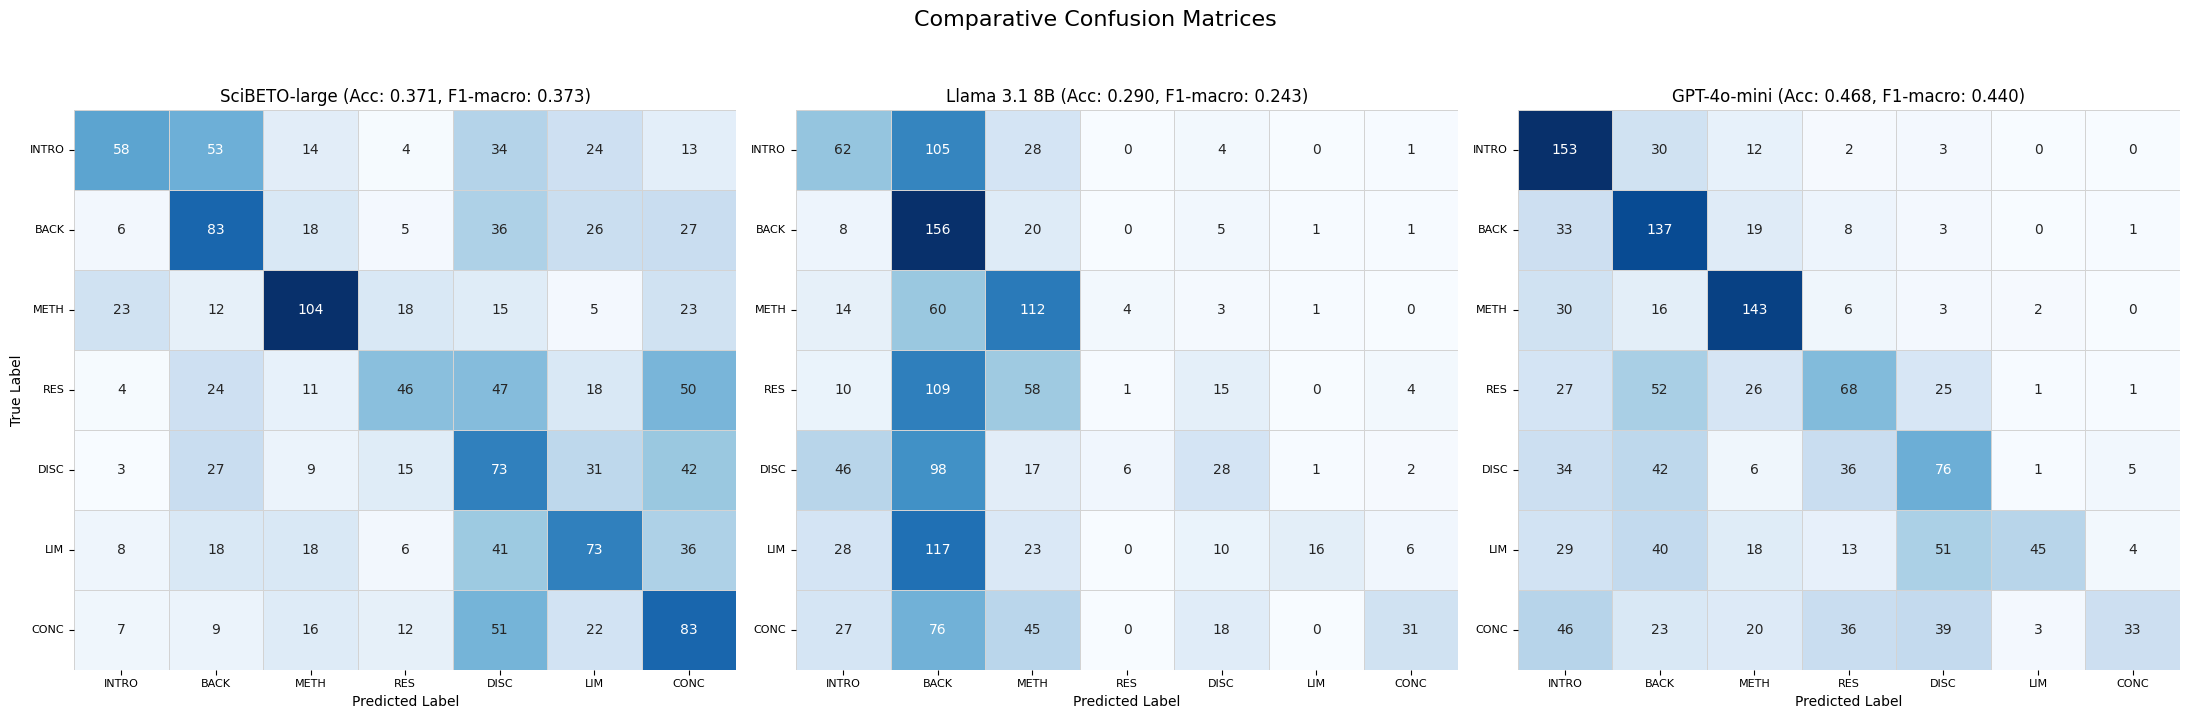

In [20]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the directory where results are stored
RESULTS_DIR = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab'

# --- Load Reports ---
def load_report(model_name: str):
    with open(f'{RESULTS_DIR}/eval_{model_name}_t1.json', 'r', encoding='utf-8') as f:
        return json.load(f)

scibeto_report = load_report('scibeto')
llama_report = load_report('llama')
gpt_report = load_report('gpt')

# --- Plot Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

reports = [scibeto_report, llama_report, gpt_report]
model_titles = [
    f"SciBETO-large (Acc: {scibeto_report['accuracy']:.3f}, F1-macro: {scibeto_report['f1_macro']:.3f})",
    f"Llama 3.1 8B (Acc: {llama_report['accuracy']:.3f}, F1-macro: {llama_report['f1_macro']:.3f})",
    f"GPT-4o-mini (Acc: {gpt_report['accuracy']:.3f}, F1-macro: {gpt_report['f1_macro']:.3f})"
]

for i, report in enumerate(reports):
    cm_df = pd.DataFrame(report['confusion_matrix'],
                         index=report['labels_order'],
                         columns=report['labels_order'])
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, linewidths=.5, linecolor='lightgray')
    axes[i].set_title(model_titles[i], fontsize=12)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    if i == 0:
        axes[i].set_ylabel('True Label', fontsize=10)
    else:
        axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8, rotation=0)

plt.suptitle('Comparative Confusion Matrices', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

/tmp/ipykernel_9004/514831355.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=metrics_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_9004/514831355.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 Macro', data=metrics_df, ax=axes[1], palette='plasma')


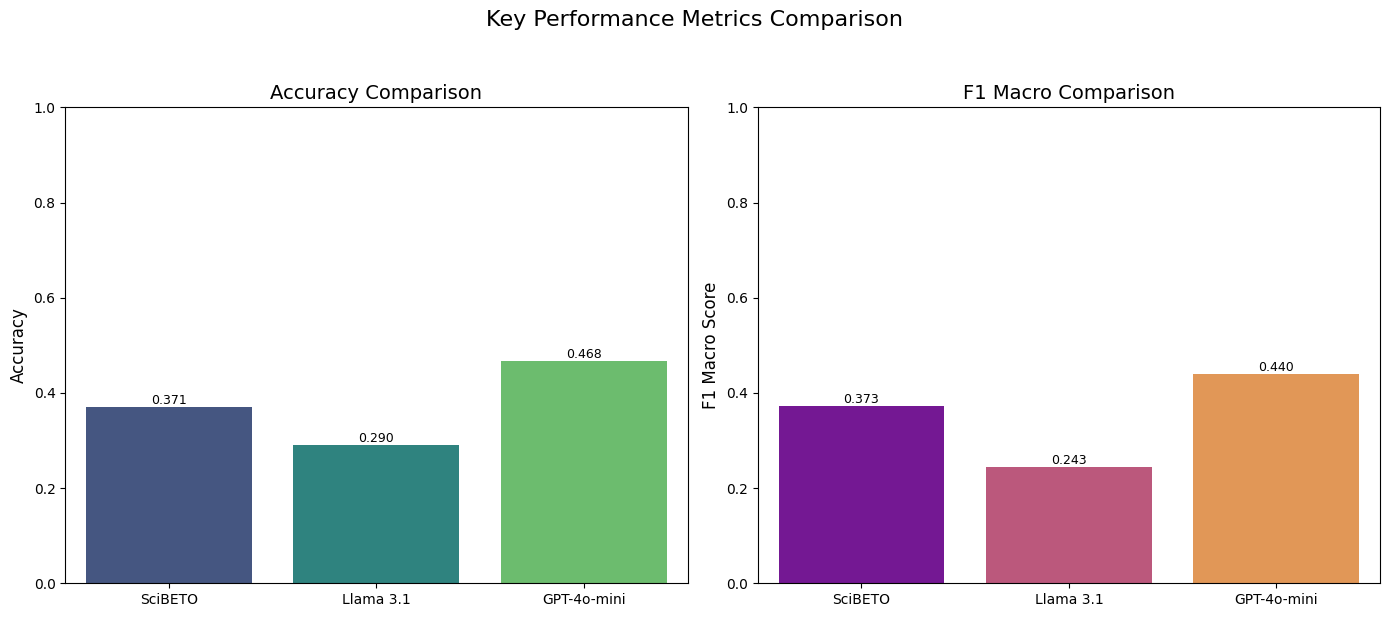

In [21]:
# --- Plot Key Metrics (Accuracy, F1 Macro) ---
metrics_data = []
for name, report in zip(['SciBETO', 'Llama 3.1', 'GPT-4o-mini'], reports):
    metrics_data.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'F1 Macro': report['f1_macro']
    })
metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy plot
sns.barplot(x='Model', y='Accuracy', data=metrics_df, ax=axes[0], palette='viridis')
axes[0].set_title('Accuracy Comparison', fontsize=14)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=9)


# F1 Macro plot
sns.barplot(x='Model', y='F1 Macro', data=metrics_df, ax=axes[1], palette='plasma')
axes[1].set_title('F1 Macro Comparison', fontsize=14)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('F1 Macro Score', fontsize=12)
axes[1].set_xlabel('')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', fontsize=9)


plt.suptitle('Key Performance Metrics Comparison', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()